# EDA 2 (Interim) - RECH1: Roster de Miembros del Hogar
Este notebook realiza la auditoría post-limpieza del módulo RECH1, que contiene las características individuales de todos los miembros del hogar (educación, edad, sexo, estado civil).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mnp.config import INTERIM_DATA_DIR

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

2026-06-15 09:28:08.284 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /Users/abelguevarah/Desktop/invs/malnutrition-research


In [2]:
DATA_PATH = INTERIM_DATA_DIR / "rech1_cleaned.parquet"
print(f"Cargando datos desde: {DATA_PATH}")
df_rech1 = pd.read_parquet(DATA_PATH)
print(f"Filas (Individuos totales): {len(df_rech1):,}")
print(f"Columnas: {len(df_rech1.columns)}")
df_rech1.head()

Cargando datos desde: /Users/abelguevarah/Desktop/invs/malnutrition-research/data/interim/rech1_cleaned.parquet
Filas (Individuos totales): 2,291,232
Columnas: 31


,HHID,HVIDX,HV101,HV102,HV103,HV104,HV105,HV106,HV107,HV108,...,HV122,HV124,HV125,HV126,HV128,year,QH13A6A,QH13A6B,QH13A6C,QH13A6D
0,1 4,1,Jefe del Hogar,Sí,Sí,Mujer,65.0,1.0,0.0,0.0,...,0.0,0.0,No,0.0,0.0,2007,NaN,NaN,NaN,NaN
1,1 4,2,Hijo/Hija,Sí,Sí,Mujer,39.0,1.0,0.0,0.0,...,0.0,0.0,No,0.0,0.0,2007,NaN,NaN,NaN,NaN
2,1 4,3,Nieto,Sí,Sí,Hombre,11.0,2.0,0.0,6.0,...,2.0,7.0,Sí,1.0,6.0,2007,NaN,NaN,NaN,NaN
3,1 10,1,Jefe del Hogar,Sí,No,Hombre,26.0,2.0,5.0,11.0,...,0.0,0.0,No,0.0,0.0,2007,NaN,NaN,NaN,NaN
4,1 10,2,Esposa o esposo,Sí,Sí,Mujer,20.0,2.0,5.0,11.0,...,0.0,0.0,No,0.0,0.0,2007,NaN,NaN,NaN,NaN


## 1. Demografía General: Edad (`HV105`) y Sexo (`HV104`)

/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_42215/3660914607.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rech1, x='HV104', palette='pastel', ax=axes[1])


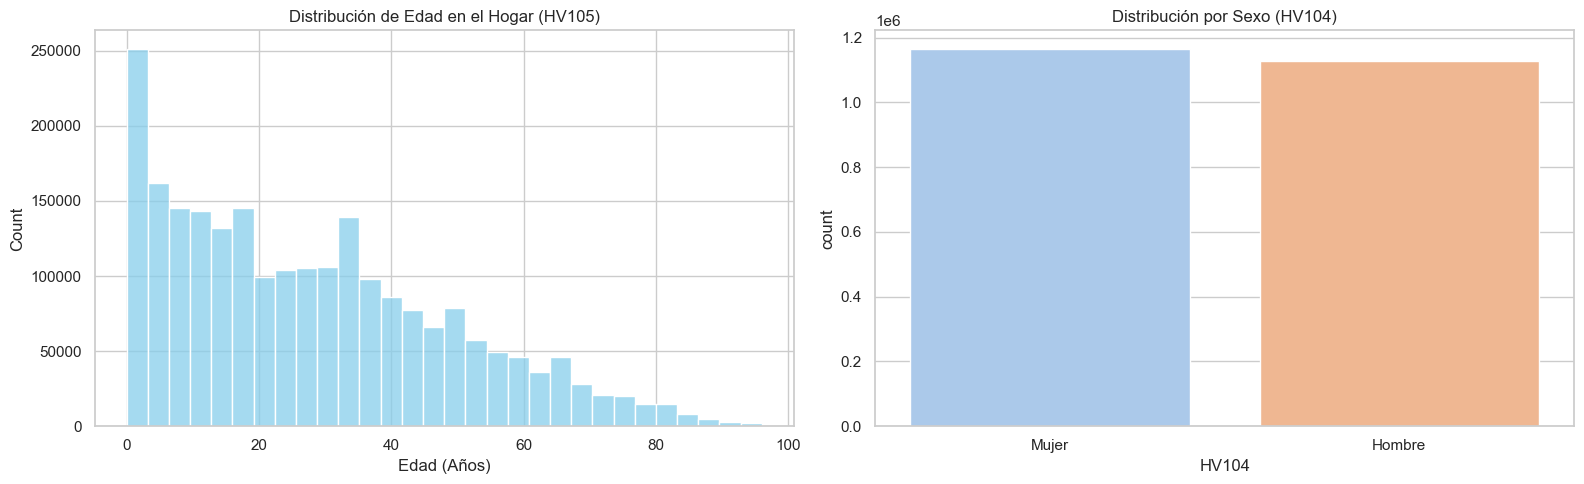

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribución de Edad
sns.histplot(df_rech1['HV105'].dropna(), bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Edad en el Hogar (HV105)')
axes[0].set_xlabel('Edad (Años)')

# Distribución de Sexo
sns.countplot(data=df_rech1, x='HV104', palette='pastel', ax=axes[1])
axes[1].set_title('Distribución por Sexo (HV104)')

plt.tight_layout()
plt.show()

> **Conclusión y Acción (Demografía General - HV105, HV104)**
> * **Observación:** La pirámide de edades muestra un pico hipertrofiado en el rango de 0 a 5 años. Lejos de ser un error, esto refleja la arquitectura intencional del muestreo de la ENDES: se busca a propósito hogares con niños pequeños para evaluar a fondo su salud. Adicionalmente, la caída natural de edades hasta los ~95 años valida que los famosos códigos "trampa" (como 98 o 99, que significan "No sabe") fueron purgados correctamente. Finalmente, la paridad de sexo (51% mujeres, 49% hombres) es estructuralmente perfecta.
> * **Acción a Tomar:** **Validación Estructural.** La integridad de la cohorte demográfica principal ha sido comprobada. No existe un sesgo de género que distorsione la muestra, y los falsos numéricos de edad fueron limpiados con éxito. Estas variables quedan listas y seguras para su futuro cruce con los datos clínicos.

## 2. Nivel Educativo (`HV109`)
El nivel educativo de la madre/padre es uno de los predictores subyacentes más fuertes de la desnutrición.

/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_42215/2163364258.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rech1, y='HV109', palette='viridis', order=sorted(df_rech1['HV109'].dropna().unique()))


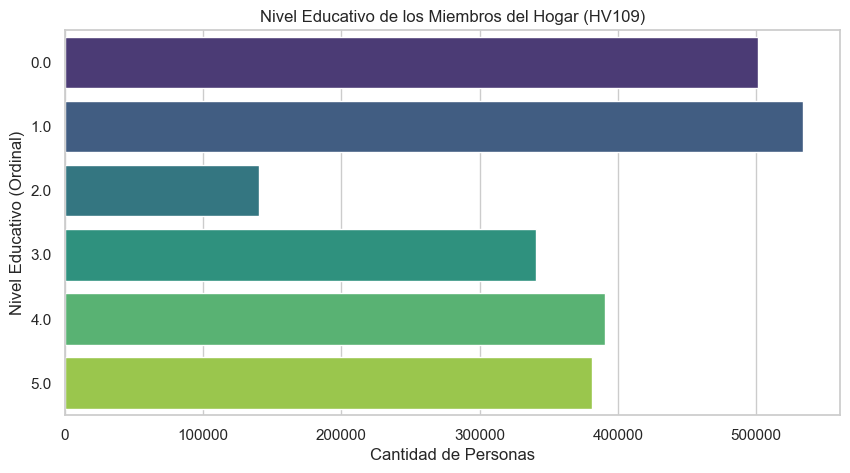

Porcentaje de Nulos en Educación (HV109): 0.11%


In [4]:
plt.figure(figsize=(10, 5))
# Ordenar por el valor del índice (1.0 a 5.0) en vez de por frecuencia, para respetar el ordinal
sns.countplot(data=df_rech1, y='HV109', palette='viridis', order=sorted(df_rech1['HV109'].dropna().unique()))
plt.title('Nivel Educativo de los Miembros del Hogar (HV109)')
plt.xlabel('Cantidad de Personas')
plt.ylabel('Nivel Educativo (Ordinal)')
plt.show()

nulos_edu = round(df_rech1['HV109'].isna().mean() * 100, 2)
print(f"Porcentaje de Nulos en Educación (HV109): {nulos_edu}%")

> **Conclusión y Acción (Nivel Educativo Global - HV109)**
> * **Observación:** El gráfico global muestra la distribución agregada de educación en las familias durante los últimos 18 años. Vemos claramente las categorías dominantes (Secundaria y Primaria).
> * **Acción a Tomar:** **Desglose Temporal Obligatorio.** Al igual que con la desnutrición, promediar 18 años de educación en el Perú esconde el masivo progreso de la política pública del país. Debemos desglosar esta variable por año para comprobar cómo la "Secundaria" y "Superior" han ganado terreno sobre la "Primaria", lo cual cambia dramáticamente el valor predictivo de la variable en el tiempo.

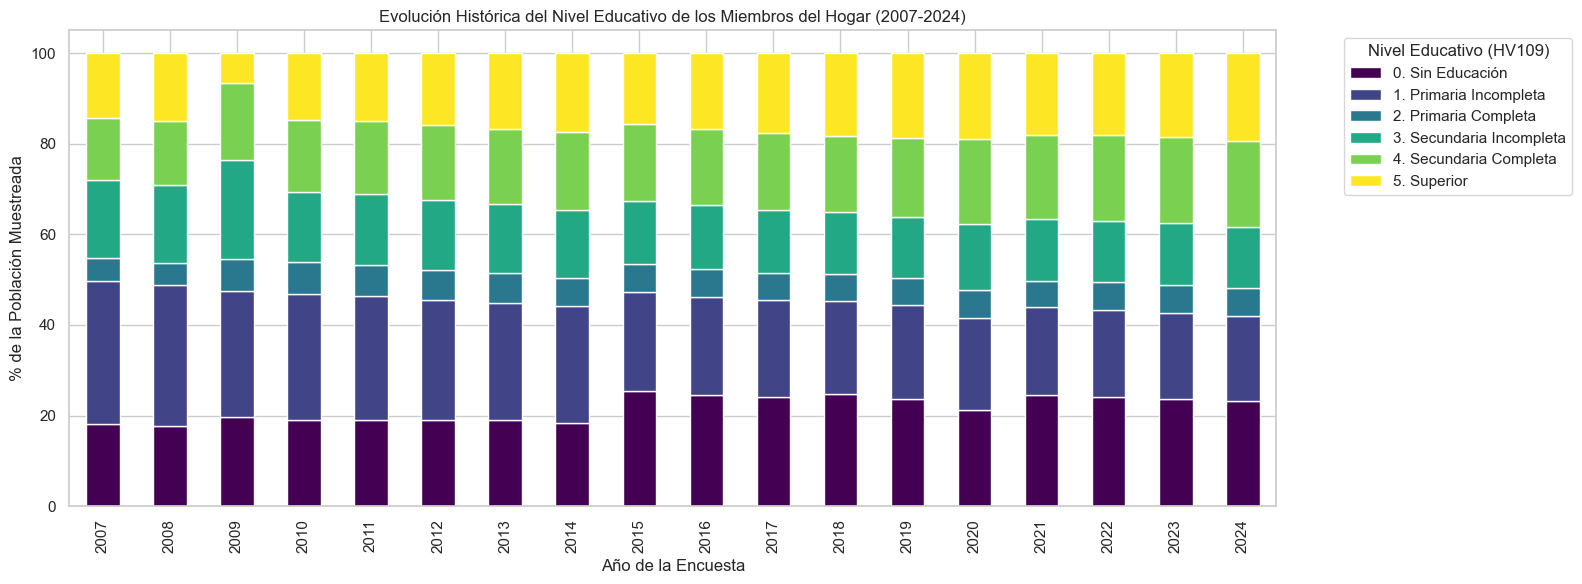

In [5]:
# Evolución Histórica del Nivel Educativo (HV109) por Año
if 'HV109' in df_rech1.columns and 'year' in df_rech1.columns:
    df_edu = df_rech1.dropna(subset=['HV109', 'year']).copy()
    
    # Estandarizar las etiquetas de educación para limpiar la inconsistencia de nombres por año
    edu_map = {
        0.0: '0. Sin Educación',
        1.0: '1. Primaria Incompleta',
        2.0: '2. Primaria Completa',
        3.0: '3. Secundaria Incompleta',
        4.0: '4. Secundaria Completa',
        5.0: '5. Superior',
        8.0: '8. No Sabe'
    }
    df_edu['HV109_Label'] = df_edu['HV109'].map(edu_map)
    
    # Eliminar 'No Sabe' si es marginal
    df_edu = df_edu[df_edu['HV109'] != 8.0]
    
    edu_balance = pd.crosstab(df_edu['year'], df_edu['HV109_Label'], normalize='index') * 100
    
    # Ordenar las columnas explícitamente de peor a mejor educación
    cols = ['0. Sin Educación', '1. Primaria Incompleta', '2. Primaria Completa', 
            '3. Secundaria Incompleta', '4. Secundaria Completa', '5. Superior']
    edu_balance = edu_balance.reindex(columns=[c for c in cols if c in edu_balance.columns])
    
    edu_balance.plot(kind='bar', stacked=True, figsize=(16, 6), colormap='viridis')
    plt.title('Evolución Histórica del Nivel Educativo de los Miembros del Hogar (2007-2024)')
    plt.ylabel('% de la Población Muestreada')
    plt.xlabel('Año de la Encuesta')
    plt.legend(title='Nivel Educativo (HV109)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

> **Conclusión y Acción (Evolución Histórica de la Educación)**
> * **Observación:** El gráfico revela dos fenómenos brutales. Primero, el **Salto Muestral de 2015**: justo en ese año vemos un incremento brusco en la franja "0. Sin Educación" (la barra morada sube del 18% al 25%). Esto confirma matemáticamente lo que hallamos en RECH6: en 2015 el INEI duplicó la muestra y logró captar a poblaciones rurales mucho más profundas/vulnerables que antes no eran encuestadas. Segundo, el **Progreso Histórico (Data Drift)**: a pesar del salto de 2015, vemos que la educación "Superior" (amarillo) casi se ha duplicado desde 2007 (saltando del 10% al 20%), mientras que la "Primaria Incompleta" se comprime sistemáticamente año tras año.
> * **Acción a Tomar:** **Estatus de Mega-Predictor Interactivo.** Para el Machine Learning, la educación es dinámica. Tener "Solo Primaria" en 2007 era lo estándar, pero tener "Solo Primaria" en 2024 (cuando la Superior y Secundaria Completa ya dominan la pirámide) es un indicador de vulnerabilidad extrema. El algoritmo (XGBoost/RF) cruzará automáticamente el Año (`year`) con el Nivel Educativo (`HV109`) para recalibrar el verdadero riesgo de desnutrición según el contexto de la época.

## 3. Estado Marital (`HV115`)

/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_42215/3307102539.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rech1, y='HV115', palette='magma')


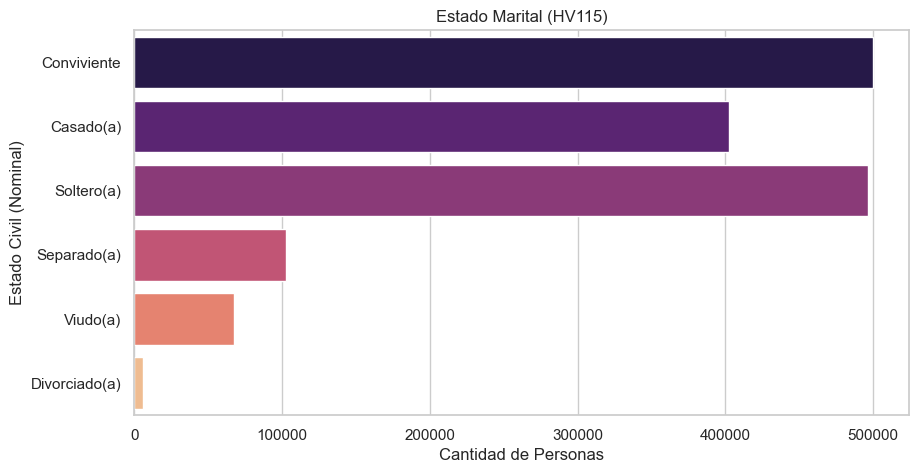

In [6]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_rech1, y='HV115', palette='magma')
plt.title('Estado Marital (HV115)')
plt.xlabel('Cantidad de Personas')
plt.ylabel('Estado Civil (Nominal)')
plt.show()

> **Conclusión y Acción (Tejido Social y Estado Marital - HV115)**
> * **Observación:** La gráfica es un espejo fiel de la realidad sociocultural peruana: la categoría "Conviviente" (unión libre) iguala a "Soltero(a)" y supera largamente al matrimonio formal ("Casado(a)"). Además, observamos más de 150,000 registros agrupados en "Separado(a)" y "Viudo(a)".
> * **Acción a Tomar:** **Feature de Vulnerabilidad (Hogares Monoparentales).** En la epidemiología social, la ausencia de un cónyuge (y potencial segundo proveedor de ingresos) se asocia matemáticamente a un estrés económico severo, impactando directamente en la calidad nutricional de la primera infancia. Esta variable (`HV115`) será valiosísima para que el algoritmo busque patrones de riesgo de desnutrición en madres solteras, viudas o separadas, cruzando esta información con su índice de riqueza.

## 4. Justificación de Variables Excluidas del Análisis Visual

El módulo `RECH1` tiene un total de 31 variables. Hemos auditado visualmente las 4 más poderosas a nivel epidemiológico (Sexo, Edad, Educación y Estado Civil). Las otras 27 variables se mantienen en el dataset intermedio (*Interim*) por diseño de arquitectura, pero no se grafican por lo siguiente:

*   **Llaves y Controles de Encuesta (13 variables)**: `HHID`, `HVIDX`, `year`, `HV102`, `HV103` (Residente habitual / Durmió anoche), `HV117` a `HV120` (Banderas de elegibilidad para otras encuestas). Son identificadores de base de datos o filtros administrativos que usa el INEI para saber a quién encuestar después.
*   **Punteros Jerárquicos (4 variables)**: `HV111` a `HV114`. Son los "Números de línea" de la madre y el padre. Son números puros (ej. Línea 2) que usaremos exclusivamente en la Fase 3 para hacer los *Joins* (buscar a la mamá del niño).
*   **Educación Redundante (3 variables)**: `HV106` (Nivel escolar), `HV107` (Año de estudio), `HV108`. Estas columnas son "materia prima" redundante. El INEI las procesa y consolida todas dentro de la variable maestra `HV109` (Nivel Educativo Alcanzado) que es la que ya graficamos.
*   **Variable de Parentesco (1 variable)**: `HV101` (Relación con el jefe del hogar). Nos sirvió para validar que el diccionario de texto funcionaba al cargar el archivo, pero al ser 2.2 millones de registros con más de 15 categorías, su gráfica es innecesaria hasta que hagamos feature engineering sobre "tipo de familia".
*   **Módulo de Seguros de Salud (4 variables)**: `QH13A6A` a `QH13A6D`. Indican si tienen SIS, EsSalud, etc. Fueron variables agregadas en años posteriores y tienen una inestabilidad histórica alta (muchos nulos en los primeros años de la década de 2000), por lo que se reservan para un análisis aislado si el modelo lo requiere.

**Nota para la Fase 4 (Modelado)**: Al igual que con Antropometría, las variables de control y redundantes serán descartadas cuando construyamos el Feature Matrix final para la Inteligencia Artificial.


## Análisis de Nulidad Estructural (Missing Values) - RECH1 (Miembros del Hogar)

Para garantizar la integridad del modelo de Machine Learning, sometemos las variables preservadas en este módulo a una prueba de nulidad histórica. 
Cualquier variable que supere el **umbral de riesgo del 60%** será considerada ruido estadístico (Data Drift) y será una candidata principal para su eliminación en la fase de *Feature Engineering*.

/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_42215/2993066105.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_nulls.head(30), x='Nulidad_Porcentaje', y='Desc', palette='Reds_r')


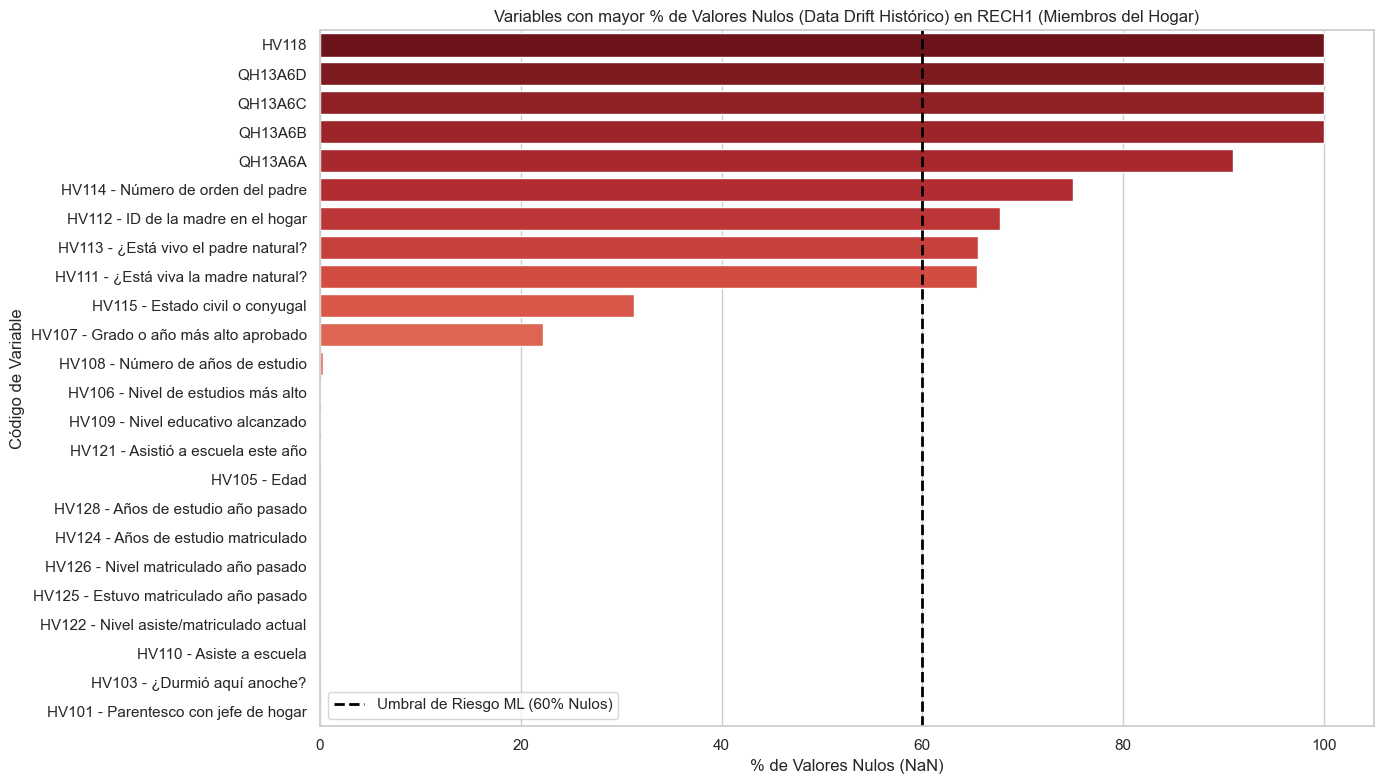

In [7]:
from mnp.config import INTERIM_DATA_DIR
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_missing = pd.read_parquet(INTERIM_DATA_DIR / 'rech1_cleaned.parquet')

nulls = df_missing.isnull().sum()
nulls_pct = (nulls / len(df_missing)) * 100
df_nulls = pd.DataFrame({'Variable': nulls_pct.index, 'Nulidad_Porcentaje': nulls_pct.values})
from mnp.configs.column_labels import LABELS
df_nulls['Desc'] = df_nulls['Variable'].map(lambda x: LABELS.get(x, x))
import textwrap
df_nulls['Desc'] = df_nulls['Desc'].apply(lambda x: textwrap.fill(str(x), width=50))
df_nulls = df_nulls[df_nulls['Nulidad_Porcentaje'] > 0].sort_values('Nulidad_Porcentaje', ascending=False)

plt.figure(figsize=(14, 8))
if len(df_nulls) > 0:
    sns.barplot(data=df_nulls.head(30), x='Nulidad_Porcentaje', y='Desc', palette='Reds_r')
    plt.title('Variables con mayor % de Valores Nulos (Data Drift Histórico) en RECH1 (Miembros del Hogar)')
    plt.xlabel('% de Valores Nulos (NaN)')
    plt.ylabel('Código de Variable')
    plt.axvline(x=60, color='black', linestyle='--', linewidth=2, label='Umbral de Riesgo ML (60% Nulos)')
    plt.legend()
else:
    plt.text(0.5, 0.5, '¡Cero Valores Nulos detectados en este Dataset!', 
             horizontalalignment='center', verticalalignment='center', fontsize=20, color='green')
    plt.axis('off')

plt.tight_layout()
plt.show()

> **Implicación para el Modelado:** Todo aquello que cruce la línea punteada negra (60%) nos indica que la pregunta no se realizó sistemáticamente a lo largo de los 18 años, o bien dependía de una sub-muestra muy pequeña. Intentar imputar estas variables destruiría la varianza del modelo.